In [1]:
pip install pandas matplotlib seaborn scikit-learn


===== DATASET INFO =====

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBillin

/tmp/ipykernel_17753/971474394.py:50: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(


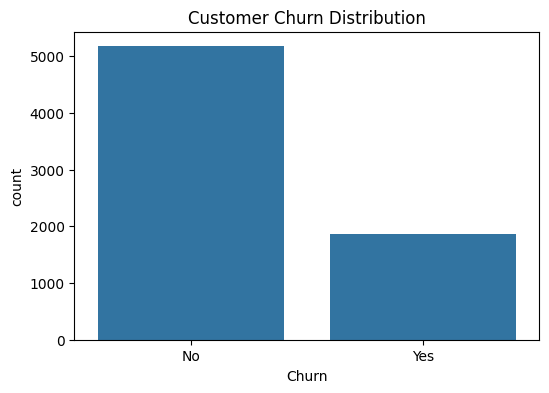

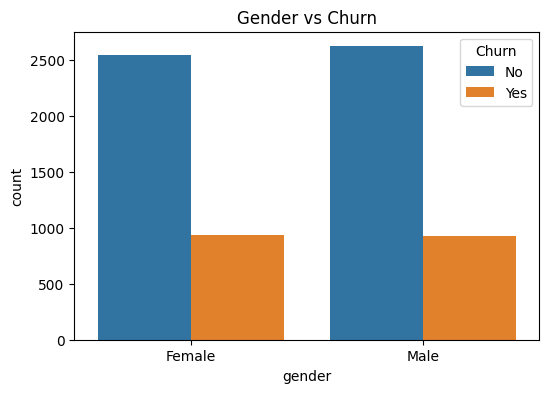

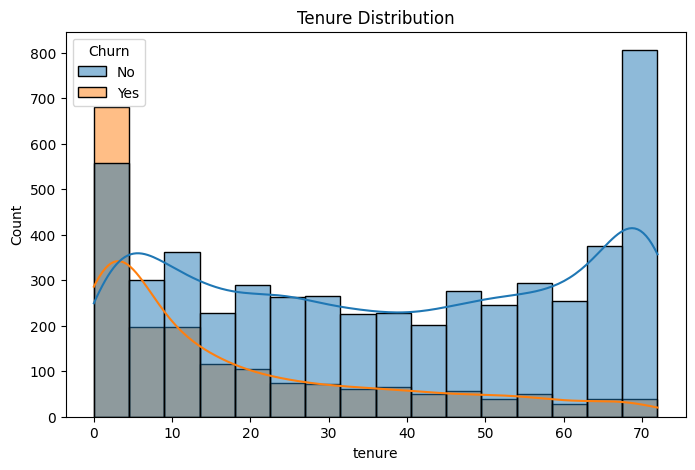

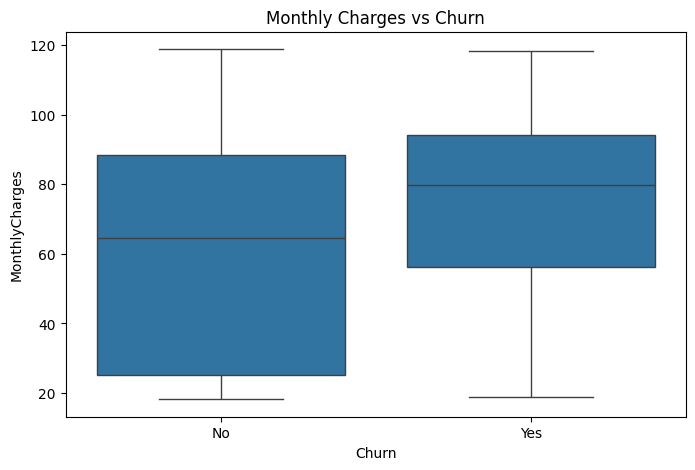

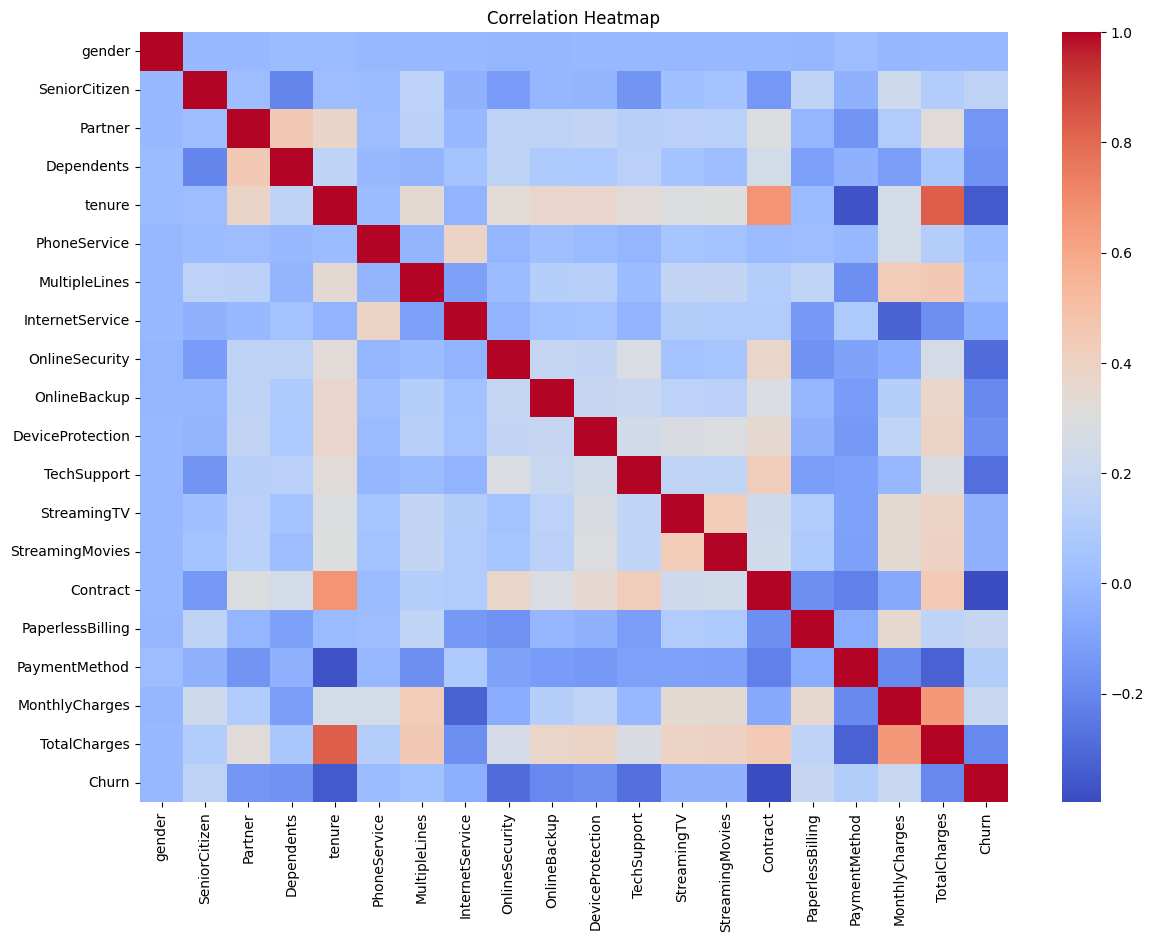


===== MODEL ACCURACY =====

Accuracy: 0.7977

===== CLASSIFICATION REPORT =====

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.48      0.56       373

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.71      1409
weighted avg       0.79      0.80      0.79      1409



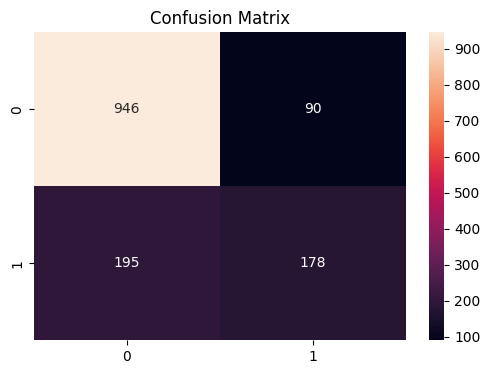

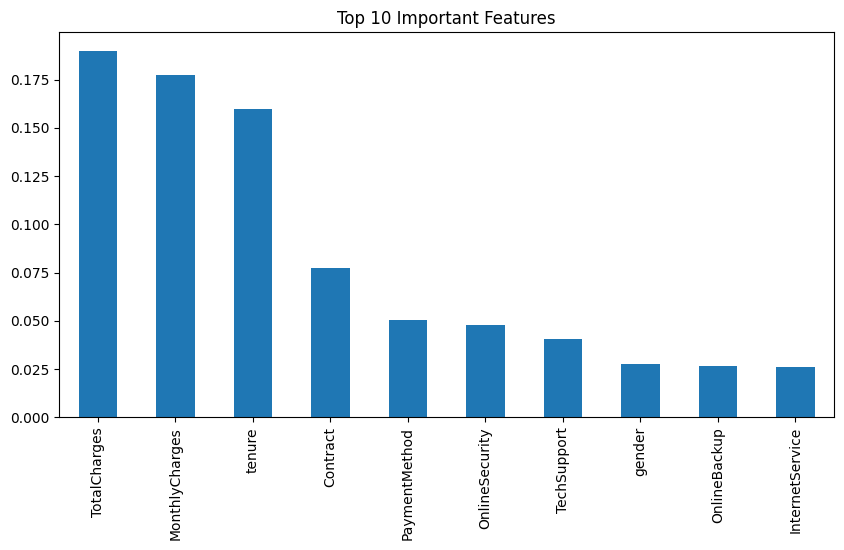


===== PROJECT COMPLETED =====


In [2]:
# ==========================================
# CUSTOMER CHURN PREDICTION PROJECT
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# ------------------------------------------
# Create folders
# ------------------------------------------

os.makedirs("charts", exist_ok=True)
os.makedirs("output", exist_ok=True)

# ------------------------------------------
# Load Dataset
# ------------------------------------------

df = pd.read_csv(
    "WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

print("\n===== DATASET INFO =====\n")
print(df.info())

print("\n===== FIRST 5 ROWS =====\n")
print(df.head())

# ------------------------------------------
# Data Cleaning
# ------------------------------------------

df.drop("customerID", axis=1, inplace=True)

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"].fillna(
    df["TotalCharges"].median(),
    inplace=True
)

# ------------------------------------------
# Save Cleaned Dataset
# ------------------------------------------

df.to_csv(
    "output/cleaned_customer_churn.csv",
    index=False
)

# ------------------------------------------
# 1. CHURN DISTRIBUTION
# ------------------------------------------

plt.figure(figsize=(6,4))

sns.countplot(
    x="Churn",
    data=df
)

plt.title("Customer Churn Distribution")

plt.savefig(
    "charts/churn_distribution.png"
)

plt.show()

# ------------------------------------------
# 2. GENDER DISTRIBUTION
# ------------------------------------------

plt.figure(figsize=(6,4))

sns.countplot(
    x="gender",
    hue="Churn",
    data=df
)

plt.title("Gender vs Churn")

plt.savefig(
    "charts/gender_vs_churn.png"
)

plt.show()

# ------------------------------------------
# 3. TENURE ANALYSIS
# ------------------------------------------

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    kde=True
)

plt.title("Tenure Distribution")

plt.savefig(
    "charts/tenure_analysis.png"
)

plt.show()

# ------------------------------------------
# 4. MONTHLY CHARGES
# ------------------------------------------

plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.title("Monthly Charges vs Churn")

plt.savefig(
    "charts/monthly_charges.png"
)

plt.show()

# ------------------------------------------
# Encode Categorical Variables
# ------------------------------------------

encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype == "object":
        df[column] = encoder.fit_transform(
            df[column]
        )

# ------------------------------------------
# Correlation Heatmap
# ------------------------------------------

plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig(
    "charts/correlation_heatmap.png"
)

plt.show()

# ------------------------------------------
# Machine Learning
# ------------------------------------------

X = df.drop("Churn", axis=1)

y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# ------------------------------------------
# Evaluation
# ------------------------------------------

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\n===== MODEL ACCURACY =====\n")
print(f"Accuracy: {accuracy:.4f}")

print("\n===== CLASSIFICATION REPORT =====\n")
print(
    classification_report(
        y_test,
        y_pred
    )
)

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")

plt.savefig(
    "charts/confusion_matrix.png"
)

plt.show()

# ------------------------------------------
# Feature Importance
# ------------------------------------------

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance.sort_values(
    ascending=False
).head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title(
    "Top 10 Important Features"
)

plt.savefig(
    "charts/feature_importance.png"
)

plt.show()

print("\n===== PROJECT COMPLETED =====")